In [1]:
import sys,os
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob

In [2]:
# set this up to point to the libararies directory in ml-holodec
dirP_str = os.path.join(os.environ['HOME'], 
                    'PythonScripts',
                    'Optics')
if dirP_str not in sys.path:
    sys.path.append(dirP_str)

In [3]:
import MieLibrary as mie

In [4]:
cset_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/CSET/","*.nc"))
cset_loc_tag = "RWOOU"

socrates_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/SOCRATES/","*.nc"))
soc_loc_tag = "CVIU"

hippo1_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-1","*.nc"))
hippo1_loc_tag = "RWI"

hippo2_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-2","*.nc"))
hippo2_loc_tag = "RWI"

hippo3_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-3","*.nc"))
hippo3_loc_tag = "RWI"

hippo4_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-4","*.nc"))
hippo4_loc_tag = "RWI"

hippo5_lst = glob.glob(os.path.join("/scr/raf/Prod_Data/HIPPO-5","*.nc"))
hippo5_loc_tag = "RWI"

# Variable Index of Refraction

In [5]:
# wavelen_lst = [1064e-9, 532e-9, 355e-9,]
# wavelen_color = ['tab:red', 'tab:green', 'tab:purple']

wavelen_lst = [1064e-9, 710e-9, 800e-9, 532e-9, 400e-9, 355e-9,] # 355, 400, 532, 710, 800, and 1064: Veselovskii et all 2002
wavelen_color = ['tab:red', 'r', 'tab:orange', 'tab:green', 'b', 'tab:purple']

real_index_refrac_lst = [1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6]
imag_index_refrac_lst = [0.0, 0.02, 0.04, 0.06]

In [6]:
number_conc_lst = []
mean_r_lst = []
mean_r_2_lst = []
mean_r_3_lst = []
mean_ln_r_lst = []
std_ln_r_lst = []
beta_coef_lst = []
alpha_coef_lst = []
file_name_lst = []
proj_name_lst = []

aircraft_vars = ['GGLAT','GGLON','GGALT','Time']
aircraft_vars_dct = {}
for var in aircraft_vars:
    aircraft_vars_dct[var] = []
aircraft_vars_attrs = {}

# postfix = 'RWOOU'  # CSET
# postfix = 'CVIU'   # SOCRATES
# postfix = 'RWI'  # HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5

# TODO also read in GGLAT, GGLON, GGALT

# file_lst = cset_lst
# file_lst = socrates_lst[4:5]
# file_lst = hippo1_lst
# file_lst = hippo2_lst
# file_lst = hippo4_lst
# file_lst = hippo5_lst

project_file_lst = [hippo1_lst, hippo2_lst, hippo3_lst, hippo4_lst, hippo5_lst]
project_str_lst = ['HIPPO-1', 'HIPPO-2', 'HIPPO-3', 'HIPPO-4', 'HIPPO-5',]
postfix_lst = [hippo1_loc_tag, hippo2_loc_tag, hippo3_loc_tag, hippo4_loc_tag, hippo5_loc_tag]

# project_file_lst = [socrates_lst, ]
# project_str_lst = ['SOCRATES',]
# postfix_lst = [soc_loc_tag,]


load_params = True

for project_idx, file_lst in enumerate(project_file_lst):
    postfix = postfix_lst[project_idx]
    project_str = project_str_lst[project_idx]

    for fidx,file in enumerate(file_lst):
        ds = xr.open_dataset(file)
        load_file = True
        
        if load_params:
            # run all the initial calculations
            try:
                part_diam = ds['CUHSAS_'+postfix].attrs['CellSizes']*1e-6
                # load_params = False
                r_arr = part_diam/2
                ang_arr = np.linspace(0,500e-6,100)
                dang=np.diff(ang_arr)
                solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)
                r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)
        
                sig_pi = np.zeros((len(wavelen_lst), len(real_index_refrac_lst), len(imag_index_refrac_lst), r_arr.size))
                sig_e = np.zeros((len(wavelen_lst), len(real_index_refrac_lst), len(imag_index_refrac_lst), r_arr.size))
                
                for wl_idx, wavelen in enumerate(wavelen_lst):
                    for re_idx, real_index in enumerate(real_index_refrac_lst):
                        for im_idx, imag_index in enumerate(imag_index_refrac_lst):
                            index_refrac = real_index+1j*imag_index
                            k_num = 2*np.pi/wavelen
                            for r_idx,r_val in enumerate(r_arr):
                                x_val = 2*np.pi*r_val/wavelen  # particle size parameter
                                Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
                                sig_pi[wl_idx,re_idx,im_idx,r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr)) # backscatter
                                sig_e[wl_idx,re_idx,im_idx,r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2  # extinction
            except KeyError:
                load_file = False
                print("Cannot load " + file)
    
        # skip loading the data if there is no UHSAS data
        if load_file:
            # dataset calculations
            beta_coef = np.zeros((len(wavelen_lst), len(real_index_refrac_lst), len(imag_index_refrac_lst), ds['Time'].size))
            alpha_coef = np.zeros((len(wavelen_lst), len(real_index_refrac_lst), len(imag_index_refrac_lst), ds['Time'].size))
            for idx in range(len(wavelen_lst)):
                for re_idx, _ in enumerate(real_index_refrac_lst):
                    for im_idx, _ in enumerate(imag_index_refrac_lst):
                        beta_coef[idx,re_idx,im_idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_pi[idx,re_idx,im_idx,:][np.newaxis,:],axis=1)/solid_angle
                        alpha_coef[idx,re_idx,im_idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_e[idx,re_idx,im_idx,:][np.newaxis,:],axis=1)
            number_conc = np.trapz(ds['CUHSAS_'+postfix].values.squeeze(),axis=1)
            
            mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
            mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
            mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
            mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
            std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
        
            valid_idx = np.where(number_conc > 0)  # locate and only use cases where the concentration is > 0
            for var in aircraft_vars_dct:
                aircraft_vars_dct[var].append(ds[var].values[valid_idx[0]])
                aircraft_vars_attrs[var] = ds[var].attrs
        
            beta_coef_lst.append(beta_coef[:,:,:,valid_idx[0]])
            alpha_coef_lst.append(alpha_coef[:,:,:,valid_idx[0]])
            number_conc_lst.append(number_conc[valid_idx[0]])
            mean_r_lst.append(mean_r[valid_idx[0]])
            mean_r_2_lst.append(mean_r_2[valid_idx[0]])
            mean_r_3_lst.append(mean_r_3[valid_idx[0]])
            mean_ln_r_lst.append(mean_ln_r[valid_idx[0]])
            std_ln_r_lst.append(std_ln_r[valid_idx[0]])
            file_name_lst.append([file.split(os.sep)[-1]]*len(valid_idx[0]))
            proj_name_lst.append([project_str]*len(valid_idx[0]))
            # file_name_lst.append(file.split(os.sep)[-1])
            # proj_name_lst.append(project_str)

/h/eol/mhayman/PythonScripts/Optics/MieLibrary.py:169: ComplexWarning: Casting complex values to real discards the imaginary part
  phi[n-1] = (2*n+3)*phi[n]/rho - phi[n+1]
/h/eol/mhayman/PythonScripts/Optics/MieLibrary.py:169: ComplexWarning: Casting complex values to real discards the imaginary part
  phi[n-1] = (2*n+3)*phi[n]/rho - phi[n+1]
/tmp/ipykernel_306914/1989269657.py:90: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_306914/1989269657.py:91: RuntimeWarning: invalid value encountered in divide
  mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
/tmp/ipykernel_306914/1989269657.py:92: RuntimeWarning: invalid value encountered in divide
  mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
/tmp/ipykernel_306914/1989269657.py:93: RuntimeWarning: invalid value e

Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf01.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf02.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf03.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf04.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf05.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf06.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf07.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf08.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf09.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf10.nc
Cannot load /scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf11.nc


/h/eol/mhayman/PythonScripts/Optics/MieLibrary.py:169: ComplexWarning: Casting complex values to real discards the imaginary part
  phi[n-1] = (2*n+3)*phi[n]/rho - phi[n+1]
/tmp/ipykernel_306914/1989269657.py:90: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_306914/1989269657.py:91: RuntimeWarning: invalid value encountered in divide
  mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
/tmp/ipykernel_306914/1989269657.py:92: RuntimeWarning: invalid value encountered in divide
  mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
/tmp/ipykernel_306914/1989269657.py:93: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_306914/1989269657.py:94: 

In [25]:
lidar_wl_str_lst = [f"{x*1e9:.02f}" for x in wavelen_lst]
aer_ds = xr.Dataset({},
           attrs={
               'description':'UHSAS aerosol data products of mean radius and number concentration and estimated lidar backscatter and extinction',
               'projects': ', '.join(np.unique(np.concatenate(proj_name_lst))),
               'lidar_wavelengths': ', '.join(lidar_wl_str_lst),
           }
          )

In [26]:
aer_ds['wavelength'] = xr.DataArray(wavelen_lst,
                                    dims=('wavelength',),
                                    attrs = {'description':'wavelength used to calculate scattering and extinction parameters',
                                             'units':'m',
                                            })

aer_ds['real_index_refraction'] = xr.DataArray(real_index_refrac_lst,
                                    dims=('real_index_refraction',),
                                    attrs = {'description':'real part of index of refraction used to calculate scattering and extinction parameters',
                                             'units':'None',
                                            })
aer_ds['imag_index_refraction'] = xr.DataArray(imag_index_refrac_lst,
                                    dims=('imag_index_refraction',),
                                    attrs = {'description':'imaginary part of index of refraction used to calculate scattering and extinction parameters',
                                             'units':'None',
                                            })

aer_ds['data_index'] = xr.DataArray(np.arange(np.concatenate(number_conc_lst,).size),dims=('data_index',),
                                    attrs = {'description':'index to data point in the dataset',})

aer_ds['backscatter_coefficient'] = xr.DataArray(np.concatenate(beta_coef_lst,axis=3),dims=('wavelength','real_index_refraction','imag_index_refraction','data_index',),
                                                 coords = {'wavelength':aer_ds['wavelength'],
                                                           'real_index_refraction':aer_ds['real_index_refraction'],
                                                           'imag_index_refraction':aer_ds['imag_index_refraction'],
                                                           'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'volume backscatter coefficient of the aerosol distribution.  Data product from an HSRL or Raman lidar',
                                                          'units':'m^{-1} sr^{-1}',}
                                                )
aer_ds['extinction_coefficient'] = xr.DataArray(np.concatenate(alpha_coef_lst,axis=3),dims=('wavelength','real_index_refraction','imag_index_refraction','data_index',),
                                                 coords = {'wavelength':aer_ds['wavelength'],
                                                           'real_index_refraction':aer_ds['real_index_refraction'],
                                                           'imag_index_refraction':aer_ds['imag_index_refraction'],
                                                           'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'volume extinction coefficient of the aerosol distribution.  Data product from an HSRL or Raman lidar',
                                                          'units':'m^{-1}',}
                                                )
aer_ds['number_concentration'] = xr.DataArray(np.concatenate(number_conc_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Number concentration of the aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'cm^{-3}',})

aer_ds['mean_r'] = xr.DataArray(np.concatenate(mean_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m',})

aer_ds['mean_r_2'] = xr.DataArray(np.concatenate(mean_r_2_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of second moment of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m^2',})

aer_ds['mean_r_3'] = xr.DataArray(np.concatenate(mean_r_3_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of third moment of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m^3',})

aer_ds['effective_r'] = xr.DataArray(aer_ds['mean_r_3'].values/aer_ds['mean_r_2'].values,dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Effective radius (third moment divided by second) of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m',})

aer_ds['std_ln_r'] = xr.DataArray(np.concatenate(std_ln_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'standard deviation of log10 of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'log10(m)',})

aer_ds['mean_log_r'] = xr.DataArray(np.concatenate(mean_ln_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of log10 of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'log10(m)',})

aer_ds['file_name'] = xr.DataArray(np.concatenate(file_name_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Name of data file the UHSAS aerosol distribution came from',
                                                          'units':'None',})
aer_ds['project_name'] = xr.DataArray(np.concatenate(proj_name_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Name of the project the UHSAS aerosol distribution came from',
                                                          'units':'None',})

# aer_ds['project_name'] = xr.DataArray(np.concatenate(proj_name_lst),dims=('data_index',),
#                                                  coords = {'data_index':aer_ds['data_index']},
#                                                  attrs = {'description':'Name of the project the UHSAS aerosol distribution came from',
#                                                           'units':'None',})
for var in aircraft_vars_dct:
    aer_ds[var] = xr.DataArray(np.concatenate(aircraft_vars_dct[var]),dims=('data_index',),
                                                     coords = {'data_index':aer_ds['data_index']},
                                                     attrs = aircraft_vars_attrs[var])

In [27]:
aer_ds.to_netcdf('/scr/tmp/mhayman/hippo_aerosol_index_training_data.nc')

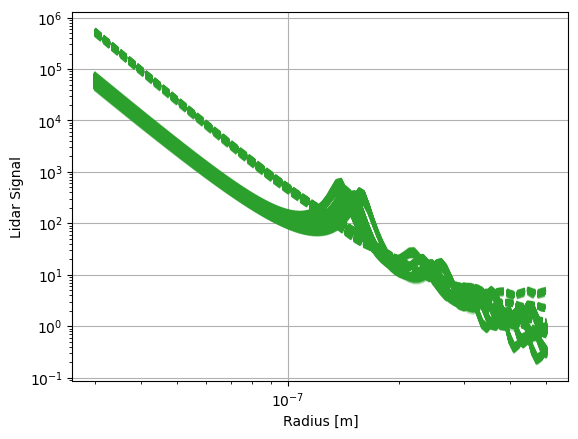

In [29]:
plt_idx = 20300 # 20000
rep_plot = 100
meas_err = 0.05
plt.figure()
# for wl_idx, wl_color in enumerate(wavelen_color):
for wl_idx in [3,]:
    wl_color = wavelen_color[wl_idx]
    for re_idx in [0,2,4,6]:
        for im_idx in [0,1,2,3]:
            for _ in range(rep_plot):
                beta_obs = beta_coef[wl_idx,re_idx,im_idx,plt_idx]*(1+np.random.randn()*meas_err)
                alpha_obs = alpha_coef[wl_idx,re_idx,im_idx,plt_idx]*(1+np.random.randn()*meas_err)
                plt.plot(r_arr,beta_obs/sig_pi[wl_idx,re_idx,im_idx,:]*solid_angle*1e-6,color=wl_color,alpha=0.3)
                plt.plot(r_arr,alpha_obs/sig_e[wl_idx,re_idx,im_idx,:]*1e-6,color=wl_color,linestyle='--',alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Radius [m]")
plt.ylabel("Lidar Signal")
plt.grid(visible=True)

In [21]:
beta_obs

NameError: name 'beta_obs' is not defined

# Fixed index of refraction

In [ ]:
# wavelen_lst = [1064e-9, 532e-9, 355e-9,]
# wavelen_color = ['tab:red', 'tab:green', 'tab:purple']

wavelen_lst = [1064e-9, 710e-9, 800e-9, 532e-9, 400e-9, 355e-9,] # 355, 400, 532, 710, 800, and 1064: Veselovskii et all 2002
wavelen_color = ['tab:red', 'red,', 'tab:orange', 'tab:green', 'blue', 'tab:purple']
index_refrac = 1.5

In [44]:
number_conc_lst = []
mean_r_lst = []
mean_r_2_lst = []
mean_r_3_lst = []
mean_ln_r_lst = []
std_ln_r_lst = []
beta_coef_lst = []
alpha_coef_lst = []
file_name_lst = []
proj_name_lst = []

aircraft_vars = ['GGLAT','GGLON','GGALT','Time']
aircraft_vars_dct = {}
for var in aircraft_vars:
    aircraft_vars_dct[var] = []
aircraft_vars_attrs = {}

# postfix = 'RWOOU'  # CSET
# postfix = 'CVIU'   # SOCRATES
# postfix = 'RWI'  # HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5

# TODO also read in GGLAT, GGLON, GGALT

# file_lst = cset_lst
# file_lst = socrates_lst[4:5]
# file_lst = hippo1_lst
# file_lst = hippo2_lst
# file_lst = hippo4_lst
# file_lst = hippo5_lst

project_file_lst = [hippo1_lst, hippo2_lst, hippo3_lst, hippo4_lst, hippo5_lst]
project_str_lst = ['HIPPO-1', 'HIPPO-2', 'HIPPO-3', 'HIPPO-4', 'HIPPO-5',]
postfix_lst = [hippo1_loc_tag, hippo2_loc_tag, hippo3_loc_tag, hippo4_loc_tag, hippo5_loc_tag]

# project_file_lst = [socrates_lst, ]
# project_str_lst = ['SOCRATES',]
# postfix_lst = [soc_loc_tag,]


load_params = True

for project_idx, file_lst in enumerate(project_file_lst):
    postfix = postfix_lst[project_idx]
    project_str = project_str_lst[project_idx]

    for fidx,file in enumerate(file_lst):
        ds = xr.open_dataset(file)
        load_file = True
        
        if load_params:
            # run all the initial calculations
            try:
                part_diam = ds['CUHSAS_'+postfix].attrs['CellSizes']*1e-6
                # load_params = False
                r_arr = part_diam/2
                ang_arr = np.linspace(0,500e-6,100)
                dang=np.diff(ang_arr)
                solid_angle = 2*np.pi*np.trapz(np.sin(ang_arr),ang_arr)
                r_mat, ang_mat = np.meshgrid(r_arr,ang_arr)
        
                sig_pi = np.zeros((len(wavelen_lst),r_arr.size))
                sig_e = np.zeros((len(wavelen_lst),r_arr.size))
                
                for wl_idx, wavelen in enumerate(wavelen_lst):
                    k_num = 2*np.pi/wavelen
                    for r_idx,r_val in enumerate(r_arr):
                        x_val = 2*np.pi*r_val/wavelen  # particle size parameter
                        Fmat = mie.Mie_PhaseMatrix(index_refrac, x_val, np.pi+ang_arr)
                        sig_pi[wl_idx,r_idx] = np.real(1/k_num**2*2*np.pi*np.trapz(Fmat[0,:]*np.sin(ang_arr),ang_arr)) # backscatter
                        sig_e[wl_idx,r_idx] = np.real(mie.CrossSections(index_refrac,x_val)[0])*(np.pi*r_val**2)/2  # extinction
            except KeyError:
                load_file = False
                print("Cannot load " + file)
    
        # skip loading the data if there is no UHSAS data
        if load_file:
            # dataset calculations
            beta_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
            alpha_coef = np.zeros((len(wavelen_lst),ds['Time'].size))
            for idx in range(len(wavelen_lst)):
                beta_coef[idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_pi[idx,:][np.newaxis,:],axis=1)/solid_angle
                alpha_coef[idx,:] = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*1e6*sig_e[idx,:][np.newaxis,:],axis=1)
            number_conc = np.trapz(ds['CUHSAS_'+postfix].values.squeeze(),axis=1)
            
            mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
            mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
            mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
            mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
            std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc - mean_ln_r**2)
        
            valid_idx = np.where(number_conc > 0)  # locate and only use cases where the concentration is > 0
            for var in aircraft_vars_dct:
                aircraft_vars_dct[var].append(ds[var].values[valid_idx[0]])
                aircraft_vars_attrs[var] = ds[var].attrs
        
            beta_coef_lst.append(beta_coef[:,valid_idx[0]])
            alpha_coef_lst.append(alpha_coef[:,valid_idx[0]])
            number_conc_lst.append(number_conc[valid_idx[0]])
            mean_r_lst.append(mean_r[valid_idx[0]])
            mean_r_2_lst.append(mean_r_2[valid_idx[0]])
            mean_r_3_lst.append(mean_r_3[valid_idx[0]])
            mean_ln_r_lst.append(mean_ln_r[valid_idx[0]])
            std_ln_r_lst.append(std_ln_r[valid_idx[0]])
            file_name_lst.append([file.split(os.sep)[-1]]*len(valid_idx[0]))
            proj_name_lst.append([project_str]*len(valid_idx[0]))
            # file_name_lst.append(file.split(os.sep)[-1])
            # proj_name_lst.append(project_str)

/tmp/ipykernel_231686/2982475357.py:85: RuntimeWarning: invalid value encountered in divide
  mean_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:],axis=1)/number_conc
/tmp/ipykernel_231686/2982475357.py:86: RuntimeWarning: invalid value encountered in divide
  mean_r_2 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**2,axis=1)/number_conc
/tmp/ipykernel_231686/2982475357.py:87: RuntimeWarning: invalid value encountered in divide
  mean_r_3 = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*r_arr[np.newaxis,:]**3,axis=1)/number_conc
/tmp/ipykernel_231686/2982475357.py:88: RuntimeWarning: invalid value encountered in divide
  mean_ln_r = np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:]),axis=1)/number_conc
/tmp/ipykernel_231686/2982475357.py:89: RuntimeWarning: invalid value encountered in divide
  std_ln_r = np.sqrt(np.trapz(ds['CUHSAS_'+postfix].values.squeeze()*np.log10(r_arr[np.newaxis,:])**2,axis=1)/number_conc

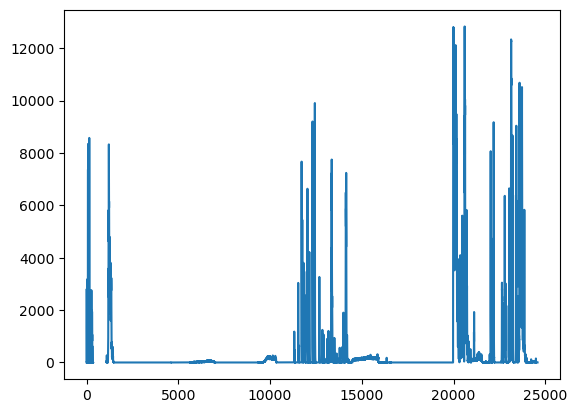

In [79]:
plt.figure()
plt.plot(np.sum(ds['CUHSAS_'+postfix].values.squeeze(),axis=1))

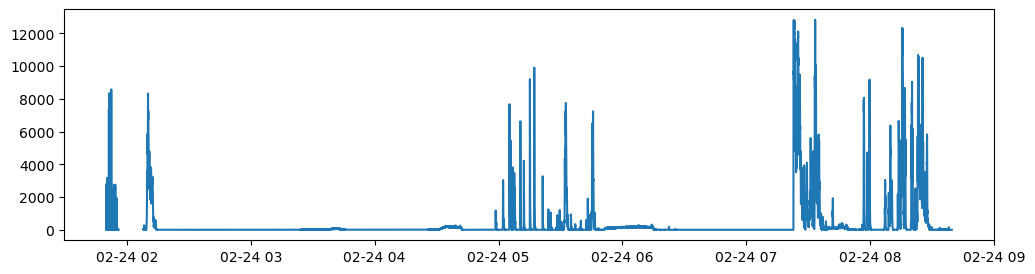

In [80]:
plt.figure(figsize=(12,3))
plt.plot(ds['Time'].values,np.sum(ds['CUHSAS_'+postfix].values.squeeze(),axis=1))

Text(0, 0.5, 'Concentration [$m^{-3}$]')

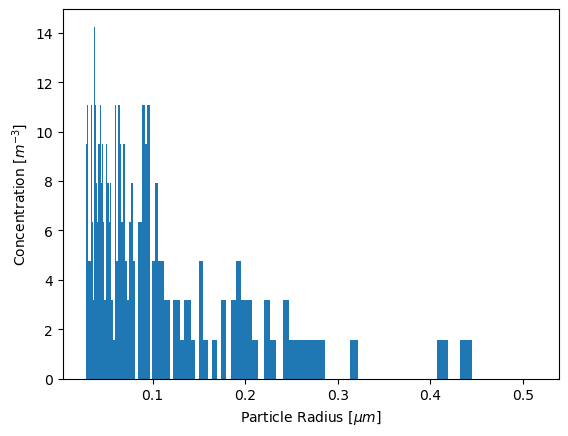

In [96]:
plt_idx = 20300 # 20000
plt.figure()
# plt.plot(r_arr*1e6,ds['CUHSAS_'+postfix].values.squeeze()[20000,:])
plt.bar(r_arr*1e6,ds['CUHSAS_'+postfix].values.squeeze()[plt_idx,:],align='edge',width=1e6*np.concatenate([np.diff(r_arr),np.diff(r_arr)[-1:]]))
plt.xlabel('Particle Radius [$\mu m$]')
plt.ylabel("Concentration [$m^{-3}$]")

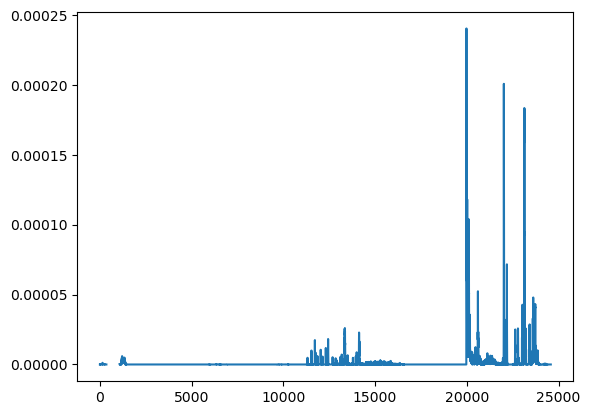

In [82]:
plt.figure()
plt.plot(beta_coef[idx,:])

In [83]:
beta_coef[:,plt_idx]

array([1.12061402e-05, 4.01328368e-05, 9.23419598e-05])

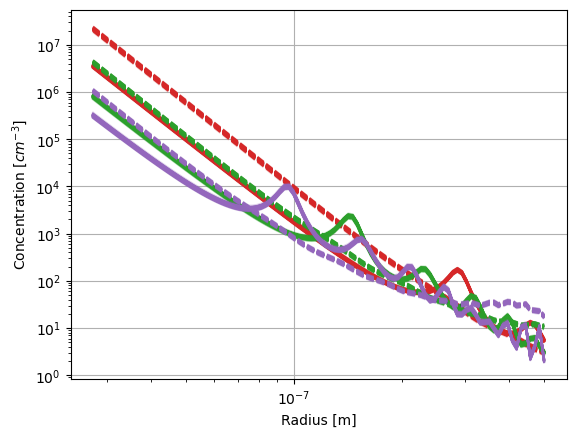

In [105]:
plt_idx = 20300 # 20000
rep_plot = 100
meas_err = 0.05
plt.figure()
for wl_idx, wl_color in enumerate(wavelen_color):
    if wl_idx in [0,1,2]:
        for _ in range(rep_plot):
            beta_obs = beta_coef[wl_idx,plt_idx]*(1+np.random.randn()*meas_err)
            alpha_obs = alpha_coef[wl_idx,plt_idx]*(1+np.random.randn()*meas_err)
            plt.plot(r_arr,beta_obs/sig_pi[wl_idx,:]*solid_angle*1e-6,color=wl_color,alpha=0.3)
            plt.plot(r_arr,alpha_obs/sig_e[wl_idx,:]*1e-6,color=wl_color,linestyle='--',alpha=0.3)
plt.xscale('log')
plt.yscale('log')
plt.xlabel("Radius [m]")
plt.ylabel("Concentration [$cm^{-3}$]")
plt.grid(visible=True)
    
    

In [108]:
np.diff(np.log10(r_arr)).size

99

In [109]:
ds['Time'].values[1] - ds['Time'].values[0]

numpy.timedelta64(1000000000,'ns')

In [86]:
number_conc[plt_idx]

12683.552

In [61]:
ds['Time'].sel(Time=np.datetime64("2018-02-05T03:47"))

<xarray.DataArray 'Time' ()>
array('2018-02-05T03:47:00.000000000', dtype='datetime64[ns]')
Coordinates:
    Time     datetime64[ns] 2018-02-05T03:47:00
Attributes:
    long_name:        time of measurement
    standard_name:    time
    strptime_format:  seconds since %F %T %z

0


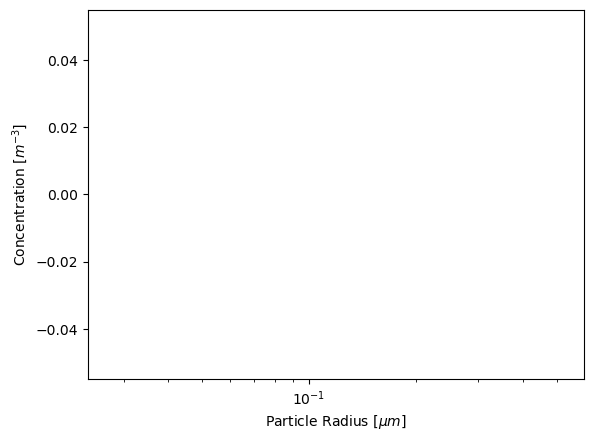

In [78]:

ds = xr.open_dataset(file_lst[-1])
plt_idx = np.argmin(np.abs(ds['Time'].values-np.datetime64("2018-02-05T03:37")))
plt.figure()
plt.bar(r_arr*1e6,ds['CUHSAS_'+postfix].values.squeeze()[plt_idx,:],align='edge',width=1e6*np.concatenate([np.diff(r_arr),np.diff(r_arr)[-1:]]))
plt.xlabel('Particle Radius [$\mu m$]')
plt.ylabel("Concentration [$m^{-3}$]")
plt.xscale('log')
print(plt_idx)

Text(0, 0.5, 'Extinction Crossection [$m^{-2}]$')

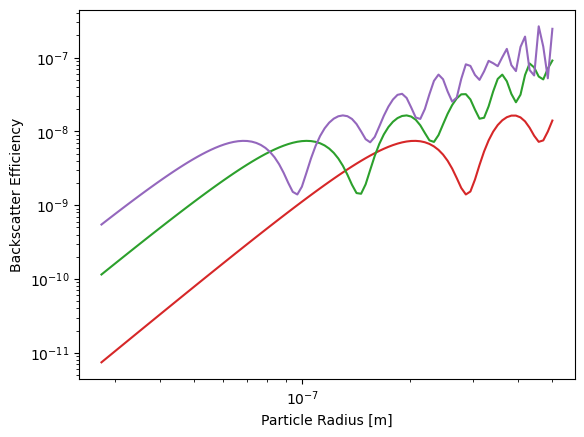

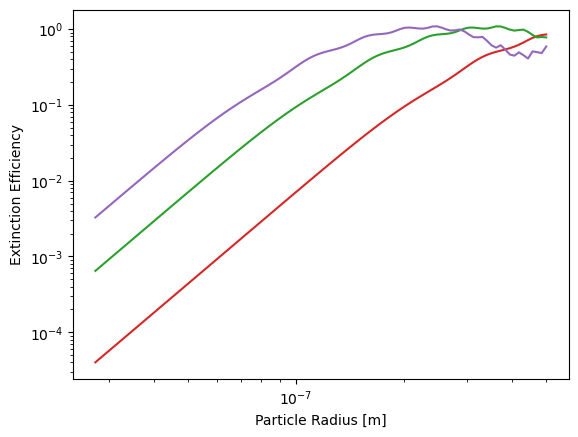

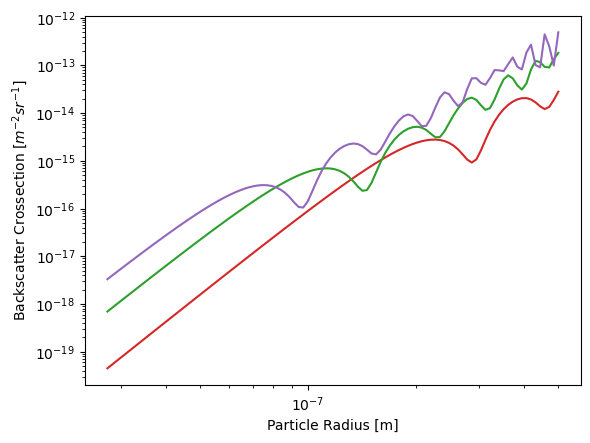

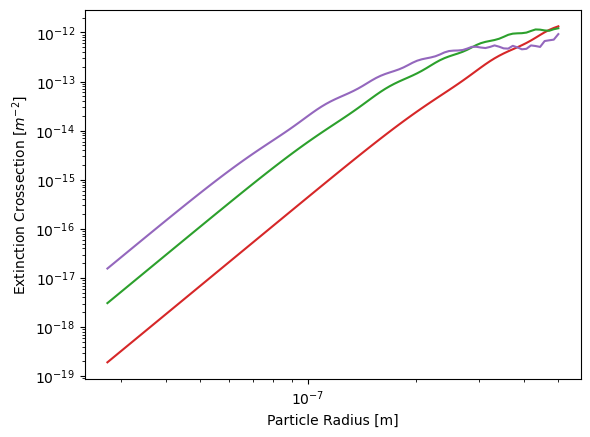

In [19]:

fig,ax = plt.subplots(1,1)
for wl_idx, wl_color in enumerate(wavelen_color):
    x_val = 2*np.pi*r_val/wavelen_lst[wl_idx]
    ax.plot(r_arr,sig_pi[wl_idx,:]/r_arr**2/2/np.pi,color=wl_color)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("Particle Radius [m]")
ax.set_ylabel("Backscatter Efficiency")

fig,ax = plt.subplots(1,1)
for wl_idx, wl_color in enumerate(wavelen_color):
    x_val = 2*np.pi*r_val/wavelen_lst[wl_idx]
    ax.plot(r_arr,sig_e[wl_idx,:]/r_arr**2/2/np.pi,color=wl_color)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("Particle Radius [m]")
ax.set_ylabel("Extinction Efficiency")



fig,ax = plt.subplots(1,1)
for wl_idx, wl_color in enumerate(wavelen_color):
    ax.plot(r_arr,sig_pi[wl_idx,:]/solid_angle,color=wl_color)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("Particle Radius [m]")
ax.set_ylabel("Backscatter Crossection [$m^{-2} sr^{-1}$]")


fig,ax = plt.subplots(1,1)
for wl_idx, wl_color in enumerate(wavelen_color):
    ax.plot(r_arr,sig_e[wl_idx,:],color=wl_color)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel("Particle Radius [m]")
ax.set_ylabel("Extinction Crossection [$m^{-2}]$")

# sig_e[wl_idx,r_idx]

In [81]:
lidar_wl_str_lst = [f"{x*1e9:.02f}" for x in wavelen_lst]
aer_ds = xr.Dataset({},
           attrs={
               'description':'UHSAS aerosol data products of mean radius and number concentration and estimated lidar backscatter and extinction',
               'projects': ', '.join(np.unique(np.concatenate(proj_name_lst))),
               'lidar_wavelengths': ', '.join(lidar_wl_str_lst),
           }
          )

In [82]:
aer_ds['wavelength'] = xr.DataArray(wavelen_lst,
                                    dims=('wavelength',),
                                    attrs = {'description':'wavelength used to calculate scattering and extinction parameters',
                                             'units':'m',
                                            })
aer_ds['data_index'] = xr.DataArray(np.arange(np.concatenate(number_conc_lst,).size),dims=('data_index',),
                                    attrs = {'description':'index to data point in the dataset',})

aer_ds['backscatter_coefficient'] = xr.DataArray(np.concatenate(beta_coef_lst,axis=1),dims=('wavelength','data_index',),
                                                 coords = {'wavelength':aer_ds['wavelength'],'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'volume backscatter coefficient of the aerosol distribution.  Data product from an HSRL or Raman lidar',
                                                          'units':'m^{-1} sr^{-1}',}
                                                )
aer_ds['extinction_coefficient'] = xr.DataArray(np.concatenate(alpha_coef_lst,axis=1),dims=('wavelength','data_index',),
                                                 coords = {'wavelength':aer_ds['wavelength'],'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'volume extinction coefficient of the aerosol distribution.  Data product from an HSRL or Raman lidar',
                                                          'units':'m^{-1}',}
                                                )
aer_ds['number_concentration'] = xr.DataArray(np.concatenate(number_conc_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Number concentration of the aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'cm^{-3}',})

aer_ds['mean_r'] = xr.DataArray(np.concatenate(mean_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m',})

aer_ds['mean_r_2'] = xr.DataArray(np.concatenate(mean_r_2_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of second moment of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m^2',})

aer_ds['mean_r_3'] = xr.DataArray(np.concatenate(mean_r_3_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of third moment of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m^3',})

aer_ds['effective_r'] = xr.DataArray(aer_ds['mean_r_3'].values/aer_ds['mean_r_2'].values,dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Effective radius (third moment divided by second) of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'m',})

aer_ds['std_ln_r'] = xr.DataArray(np.concatenate(std_ln_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'standard deviation of log10 of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'log10(m)',})

aer_ds['mean_log_r'] = xr.DataArray(np.concatenate(mean_ln_r_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Mean of log10 of particle radius of aerosol distribution.  Calculated from UHSAS size distribution data',
                                                          'units':'log10(m)',})

aer_ds['file_name'] = xr.DataArray(np.concatenate(file_name_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Name of data file the UHSAS aerosol distribution came from',
                                                          'units':'None',})
aer_ds['project_name'] = xr.DataArray(np.concatenate(proj_name_lst),dims=('data_index',),
                                                 coords = {'data_index':aer_ds['data_index']},
                                                 attrs = {'description':'Name of the project the UHSAS aerosol distribution came from',
                                                          'units':'None',})

# aer_ds['project_name'] = xr.DataArray(np.concatenate(proj_name_lst),dims=('data_index',),
#                                                  coords = {'data_index':aer_ds['data_index']},
#                                                  attrs = {'description':'Name of the project the UHSAS aerosol distribution came from',
#                                                           'units':'None',})
for var in aircraft_vars_dct:
    aer_ds[var] = xr.DataArray(np.concatenate(aircraft_vars_dct[var]),dims=('data_index',),
                                                     coords = {'data_index':aer_ds['data_index']},
                                                     attrs = aircraft_vars_attrs[var])

In [83]:
aer_ds.to_netcdf('/scr/tmp/mhayman/hippo_aerosol_training_data.nc')
# aer_ds.to_netcdf('/scr/tmp/mhayman/socrates_aerosol_training_data.nc')

In [89]:
ds['CUHSAS_'+postfix]

<xarray.DataArray 'CUHSAS_CVIU' (Time: 24661, sps1: 1, Vector100: 100)>
array([[[ 0.,  0., ...,  0.,  0.]],

       [[ 0.,  0., ...,  0.,  0.]],

       ...,

       [[ 0., nan, ..., nan, nan]],

       [[ 0., nan, ..., nan, nan]]], dtype=float32)
Coordinates:
  * Time     (Time) datetime64[ns] 2018-02-24T01:50:00 ... 2018-02-24T08:41:00
Dimensions without coordinates: sps1, Vector100
Attributes: (12/13)
    units:          #/cm3
    long_name:      UHSAS Ambient Concentration (per cell)
    actual_range:   [   0.    8344.203]
    Category:       PMS Probe
    SerialNumber:   UHSAS015
    DataQuality:    Good
    ...             ...
    FirstBin:       1
    LastBin:        100
    CellSizes:      [0.055   0.05664 0.05832 0.06005 0.06184 0.06368 0.06557 ...
    CellSizeUnits:  micrometers
    CellSizeNote:   CellSizes are upper bin limits as diameter.
    HistogramNote:  Zeroth data bin is an unused legacy placeholder.

In [84]:
cov_mat = np.cov(np.concatenate([np.concatenate(alpha_coef_lst,axis=1),
                np.concatenate(beta_coef_lst,axis=1),
                np.concatenate(number_conc_lst,).reshape(1,-1),
                np.concatenate(mean_r_lst).reshape(1,-1)],axis=0))

In [85]:
cov_mat

array([[6.89722803e-10, 1.97323320e-09, 2.28727384e-09, 2.28016655e-11,
        8.24844248e-11, 1.81843916e-10, 2.73293538e-02, 1.81861703e-13],
       [1.97323320e-09, 5.81203356e-09, 6.89462253e-09, 6.71726604e-11,
        2.38241141e-10, 5.25075541e-10, 8.75436512e-02, 5.10712083e-13],
       [2.28727384e-09, 6.89462253e-09, 8.33573290e-09, 7.97877821e-11,
        2.78619204e-10, 6.13574045e-10, 1.12169653e-01, 5.86605731e-13],
       [2.28016655e-11, 6.71726604e-11, 7.97877821e-11, 7.77935437e-13,
        2.75539267e-12, 6.07109480e-12, 1.02627355e-03, 5.97238456e-15],
       [8.24844248e-11, 2.38241141e-10, 2.78619204e-10, 2.75539267e-12,
        9.91109438e-12, 2.18156760e-11, 3.45293891e-03, 2.17227234e-14],
       [1.81843916e-10, 5.25075541e-10, 6.13574045e-10, 6.07109480e-12,
        2.18156760e-11, 4.81587447e-11, 7.53913396e-03, 4.76976929e-14],
       [2.73293538e-02, 8.75436512e-02, 1.12169653e-01, 1.02627355e-03,
        3.45293891e-03, 7.53913396e-03, 2.07525398e+06, 6.

In [86]:
cor_mat = np.corrcoef(np.concatenate([np.concatenate(alpha_coef_lst,axis=1),
                np.concatenate(beta_coef_lst,axis=1),
                np.concatenate(number_conc_lst,).reshape(1,-1),
                np.concatenate(mean_r_lst).reshape(1,-1)],axis=0))

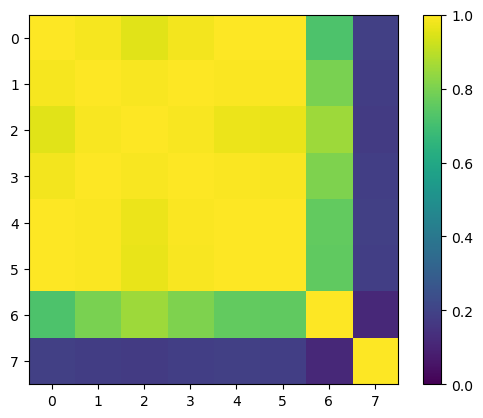

In [87]:
plt.figure()
plt.imshow(cor_mat,vmin=0,vmax=1)
plt.colorbar()

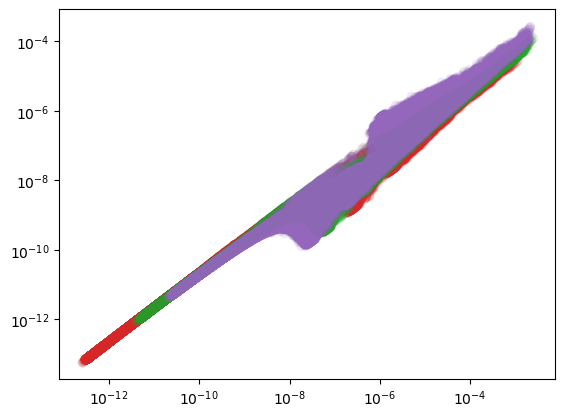

In [88]:
plt.figure()
plt.scatter(np.concatenate(alpha_coef_lst,axis=1)[0,:],np.concatenate(beta_coef_lst,axis=1)[0,:],c=wavelen_color[0],alpha=0.1)
plt.scatter(np.concatenate(alpha_coef_lst,axis=1)[1,:],np.concatenate(beta_coef_lst,axis=1)[1,:],c=wavelen_color[1],alpha=0.1)
plt.scatter(np.concatenate(alpha_coef_lst,axis=1)[2,:],np.concatenate(beta_coef_lst,axis=1)[2,:],c=wavelen_color[2],alpha=0.1)
plt.xscale('log')
plt.yscale('log')

# Split the dataset into training, validation and test data

In [28]:
ds_name = 'hippo_aerosol_index_training_data.nc'
load_path = '/scr/tmp/mhayman/'
ds = xr.load_dataset(os.path.join(load_path,ds_name))

In [29]:
split_ratio_train = 0.6
split_ratio_valid = 0.3
split_ratio_test = 1-split_ratio_train-split_ratio_valid

In [30]:
ds.sizes['data_index']

1144606

In [31]:
flight_lst = np.unique(ds['file_name'].values)

In [32]:
train_ds_count = int(np.round(flight_lst.size*split_ratio_train))
valid_ds_count = int(np.round(flight_lst.size*split_ratio_valid))

In [33]:
ds_idx_full = np.arange(flight_lst.size)
train_ds_idx = np.random.choice(ds_idx_full,train_ds_count,replace=False)
ds_idx_remain = np.delete(ds_idx_full,train_ds_idx)
valid_ds_idx = np.random.choice(ds_idx_remain,valid_ds_count,replace=False)
test_ds_idx = np.delete(ds_idx_full,np.concatenate([train_ds_idx,valid_ds_idx]))

In [34]:
data_idx_lst = []
for flt_idx in train_ds_idx:
    data_idx = np.where(flight_lst[flt_idx] == ds['file_name'].values)[0]
    data_idx_lst.append(data_idx)

train_ds = ds.sel({'data_index':np.concatenate(data_idx_lst)})
print(train_ds.sizes['data_index'])

data_idx_lst = []
for flt_idx in valid_ds_idx:
    data_idx = np.where(flight_lst[flt_idx] == ds['file_name'].values)[0]
    data_idx_lst.append(data_idx)

valid_ds = ds.sel({'data_index':np.concatenate(data_idx_lst)})
print(valid_ds.sizes['data_index'])

data_idx_lst = []
for flt_idx in test_ds_idx:
    data_idx = np.where(flight_lst[flt_idx] == ds['file_name'].values)[0]
    data_idx_lst.append(data_idx)

test_ds = ds.sel({'data_index':np.concatenate(data_idx_lst)})
print(test_ds.sizes['data_index'])

724733
302614
117259


In [35]:
train_ds.to_netcdf(os.path.join(load_path, ds_name.replace('.nc','_train.nc')))
valid_ds.to_netcdf(os.path.join(load_path,ds_name.replace('.nc','_valid.nc')))
test_ds.to_netcdf(os.path.join(load_path,ds_name.replace('.nc','_test.nc')))

In [39]:
np.sum(np.isnan(train_ds['extinction_coefficient'].values))

0

In [41]:
np.sum(np.isnan(train_ds['effective_r'].values))

0

In [20]:
ds['real_index_refraction']

<xarray.DataArray 'real_index_refraction' (real_index_refraction: 7)>
array([0, 1, 2, 3, 4, 5, 6])
Coordinates:
  * real_index_refraction  (real_index_refraction) int64 0 1 2 3 4 5 6

In [21]:
real_index_refrac_lst

[1.3, 1.35, 1.4, 1.45, 1.5, 1.55, 1.6]

In [22]:
imag_index_refrac_lst

[0.0, 0.02, 0.04, 0.06]

In [23]:
xr.DataArray(real_index_refrac_lst,
            dims=('real_index_refraction',),
            attrs = {'description':'real part of index of refraction used to calculate scattering and extinction parameters',
                     'units':'None',
                    })

<xarray.DataArray (real_index_refraction: 7)>
array([1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 ])
Dimensions without coordinates: real_index_refraction
Attributes:
    description:  real part of index of refraction used to calculate scatteri...
    units:        None

In [24]:
aer_ds['real_index_refraction']

<xarray.DataArray 'real_index_refraction' (real_index_refraction: 7)>
array([0, 1, 2, 3, 4, 5, 6])
Coordinates:
  * real_index_refraction  (real_index_refraction) int64 0 1 2 3 4 5 6

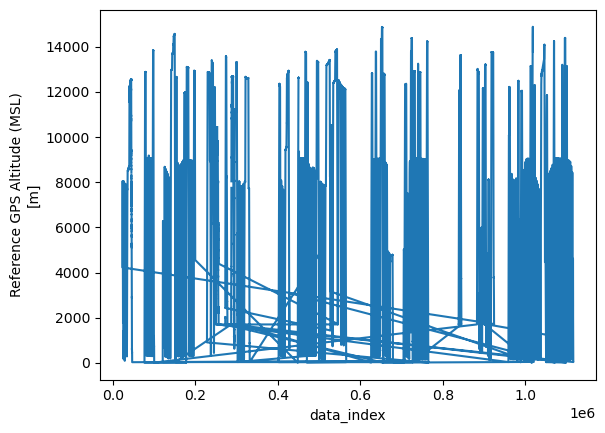

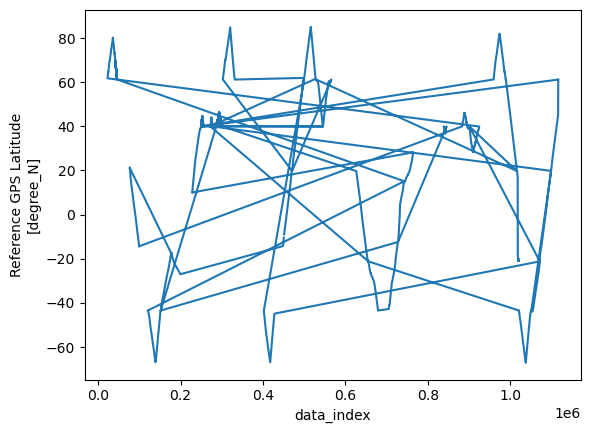

In [145]:
plt.figure()
train_ds['GGALT'].plot()

plt.figure()
train_ds['GGLAT'].plot()

In [147]:
np.unique(train_ds['file_name'].values)

array(['HIPPO-1rf03.nc', 'HIPPO-1rf05.nc', 'HIPPO-1rf07.nc',
       'HIPPO-1rf08.nc', 'HIPPO-1rf09.nc', 'HIPPO-1rf11.nc',
       'HIPPO-1tf01.nc', 'HIPPO-1tf02.nc', 'HIPPO-1tf03.nc',
       'HIPPO-2tf02.nc', 'HIPPO-3rf02.nc', 'HIPPO-3rf06.nc',
       'HIPPO-3rf08.nc', 'HIPPO-3rf09.nc', 'HIPPO-3rf10.nc',
       'HIPPO-3rf11.nc', 'HIPPO-4rf01.nc', 'HIPPO-4rf04.nc',
       'HIPPO-4rf05.nc', 'HIPPO-4rf07.nc', 'HIPPO-4rf08.nc',
       'HIPPO-4rf09.nc', 'HIPPO-4tf01.nc', 'HIPPO-5rf01.nc',
       'HIPPO-5rf02.nc', 'HIPPO-5rf05.nc', 'HIPPO-5rf06.nc',
       'HIPPO-5rf07.nc', 'HIPPO-5rf09.nc', 'HIPPO-5rf10.nc',
       'HIPPO-5rf11.nc', 'HIPPO-5rf12.nc'], dtype=object)

In [148]:
np.unique(valid_ds['file_name'].values)

array(['HIPPO-1rf02.nc', 'HIPPO-1rf06.nc', 'HIPPO-1rf10.nc',
       'HIPPO-3rf03.nc', 'HIPPO-3rf04.nc', 'HIPPO-3rf05.nc',
       'HIPPO-3rf07.nc', 'HIPPO-4rf02.nc', 'HIPPO-4rf03.nc',
       'HIPPO-4rf06.nc', 'HIPPO-4rf10.nc', 'HIPPO-4rf11.nc',
       'HIPPO-4rf12.nc', 'HIPPO-4tf02.nc', 'HIPPO-5ff01.nc',
       'HIPPO-5rf04.nc'], dtype=object)

In [146]:
train_ds

<xarray.Dataset>
Dimensions:                  (wavelength: 3, data_index: 683577)
Coordinates:
  * wavelength               (wavelength) float64 1.064e-06 5.32e-07 3.55e-07
  * data_index               (data_index) int64 177282 177283 ... 1050743
Data variables: (12/14)
    backscatter_coefficient  (wavelength, data_index) float64 1.122e-07 ... 5...
    extinction_coefficient   (wavelength, data_index) float64 1.484e-06 ... 9...
    number_concentration     (data_index) float32 890.8 908.9 ... 1.097e+03
    mean_r                   (data_index) float32 7.882e-08 ... 5.969e-08
    mean_r_2                 (data_index) float32 7.258e-15 ... 4.511e-15
    mean_r_3                 (data_index) float32 8.291e-22 ... 5.217e-22
    ...                       ...
    file_name                (data_index) object 'HIPPO-1rf09.nc' ... 'HIPPO-...
    project_name             (data_index) object 'HIPPO-1' ... 'HIPPO-5'
    GGLAT                    (data_index) float32 -17.56 -17.56 ... -43.48
    GGLON                    (data_index) float32 -149.6 -149.6 ... 172.5 172.5
    GGALT                    (data_index) float32 5.542 5.474 ... 36.39 36.39
    Time                     (data_index) datetime64[ns] 2009-01-26T02:22:00 ...
Attributes:
    description:        UHSAS aerosol data products of mean radius and number...
    projects:           HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5
    lidar_wavelengths:  1064.00, 532.00, 355.00

In [107]:
train_ds_count = int(np.round(ds.sizes['data_index']*split_ratio_train))
valid_ds_count = int(np.round(ds.sizes['data_index']*split_ratio_valid))

In [108]:
ds.sizes['data_index']

1144606

In [109]:
ds_idx_full = ds['data_index'].values.copy()
train_ds_idx = np.random.choice(ds_idx_full,train_ds_count,replace=False)
ds_idx_remain = np.delete(ds_idx_full,train_ds_idx)
valid_ds_idx = np.random.choice(ds_idx_remain,valid_ds_count,replace=False)
test_ds_idx = np.delete(ds_idx_full,np.concatenate([train_ds_idx,valid_ds_idx]))

In [110]:
train_ds = ds.sel({'data_index':train_ds_idx})
train_ds.to_netcdf(os.path.join(load_path, ds_name.replace('.nc','_train.nc')))
valid_ds = ds.sel({'data_index':valid_ds_idx})
valid_ds.to_netcdf(os.path.join(load_path,ds_name.replace('.nc','_valid.nc')))
test_ds = ds.sel({'data_index':test_ds_idx})
test_ds.to_netcdf(os.path.join(load_path,ds_name.replace('.nc','_test.nc')))

In [116]:
valid_ds.sizes['data_index']/256

1341.3359375

In [102]:
ds

<xarray.Dataset>
Dimensions:                  (wavelength: 3, data_index: 1144606)
Coordinates:
  * wavelength               (wavelength) float64 1.064e-06 5.32e-07 3.55e-07
  * data_index               (data_index) int64 0 1 2 ... 1144604 1144605
Data variables: (12/14)
    backscatter_coefficient  (wavelength, data_index) float64 5.259e-08 ... 3...
    extinction_coefficient   (wavelength, data_index) float64 1.076e-06 ... 1...
    number_concentration     (data_index) float32 1.035e+03 862.3 ... 139.2
    mean_r                   (data_index) float32 6.561e-08 ... 6.832e-08
    mean_r_2                 (data_index) float32 4.814e-15 ... 6.668e-15
    mean_r_3                 (data_index) float32 4.525e-22 ... 1.115e-21
    ...                       ...
    file_name                (data_index) object 'HIPPO-1rf01.nc' ... 'HIPPO-...
    project_name             (data_index) object 'HIPPO-1' ... 'HIPPO-5'
    GGLAT                    (data_index) float32 39.91 39.91 ... 61.18 61.18
    GGLON                    (data_index) float32 -105.1 -105.1 ... -150.0
    GGALT                    (data_index) float32 1.718e+03 1.718e+03 ... 37.13
    Time                     (data_index) datetime64[ns] 2009-01-08T16:08:35 ...
Attributes:
    description:        UHSAS aerosol data products of mean radius and number...
    projects:           HIPPO-1, HIPPO-2, HIPPO-3, HIPPO-4, HIPPO-5
    lidar_wavelengths:  1064.00, 532.00, 355.00

In [35]:
beta_coef_lst[1].shape

(3, 18849)

In [18]:
part_diam

array([7.50000027e-08, 7.69899984e-08, 7.90300021e-08, 8.11199996e-08,
       8.32699953e-08, 8.54799964e-08, 8.77500028e-08, 9.00700030e-08,
       9.24599988e-08, 9.49099999e-08, 9.74299965e-08, 1.00009999e-07,
       1.02660003e-07, 1.05389994e-07, 1.08180004e-07, 1.11049999e-07,
       1.36899999e-07, 1.40530005e-07, 1.44260000e-07, 1.48080005e-07,
       1.52009989e-07, 1.56040002e-07, 1.60170003e-07, 1.64419987e-07,
       1.68780005e-07, 1.73250001e-07, 1.77839993e-07, 1.82560001e-07,
       1.87400005e-07, 1.92369995e-07, 1.97469987e-07, 2.02700008e-07,
       2.08069991e-07, 2.13589999e-07, 2.63320004e-07, 2.70300006e-07,
       2.77469979e-07, 2.84819976e-07, 2.92370004e-07, 3.00120007e-07,
       3.08079990e-07, 3.16250009e-07, 3.24629980e-07, 3.33239996e-07,
       3.42070024e-07, 3.51139988e-07, 3.60450002e-07, 3.70000009e-07,
       3.79810018e-07, 3.89880000e-07, 4.00220017e-07, 4.10829983e-07,
       4.21719989e-07, 4.32900009e-07, 4.44369988e-07, 4.56149991e-07,
      

In [19]:
file

'/scr/raf/Prod_Data/HIPPO-2/HIPPO-2rf01.nc'

In [20]:
ds

<xarray.Dataset>
Dimensions:                 (Time: 22707, sps1: 1, Vector31: 31,
                             interarrival_endpoints: 41, Vector129: 129)
Coordinates:
  * Time                    (Time) datetime64[ns] 2009-10-31T16:20:30 ... 200...
  * interarrival_endpoints  (interarrival_endpoints) float32 1e-07 ... 10.0
Dimensions without coordinates: sps1, Vector31, Vector129
Data variables: (12/156)
    ACDP_LWI                (Time, sps1, Vector31) float32 ...
    ADIFR                   (Time) float32 ...
    BDIFR                   (Time) float32 ...
    BLATA                   (Time) float32 ...
    BLONGA                  (Time) float32 ...
    BNORMA                  (Time) float32 ...
    ...                      ...
    NACCEPT2DCR_LWO         (Time) float32 ...
    NACCEPT2DCA_LWO         (Time) float32 ...
    NREJECT2DCR_LWO         (Time) float32 ...
    NREJECT2DCA_LWO         (Time) float32 ...
    WIF                     (Time) float32 ...
    WIX                     (Time) float32 ...
Attributes: (12/40)
    institution:                   NCAR Research Aviation Facility
    Address:                       P.O. Box 3000, Boulder, CO 80307-3000
    Phone:                         (303) 497-1030
    creator_url:                   http://www.eol.ucar.edu
    creator_email:                 codiac at ucar.edu
    Conventions:                   NCAR-RAF/nimbus
    ...                            ...
    landmarks:                     39.9083 -105.116 BJC,61.1741 -149.996 ANC,...
    Categories:                    Position,Thermodynamic,Aircraft State,Atmo...
    time_coverage_start:           2009-10-31T16:20:30 +0000
    time_coverage_end:             2009-10-31T22:38:56 +0000
    history:                       Thu Nov 10 02:20:22 2016: ncks -a -v ^.*1D...
    NCO:                           4.4.4

In [66]:
number_conc_lst

[array([1035.3445 ,  862.2571 ,  810.35626, ...,  257.39334,  252.14883,
         260.06305], dtype=float32),
 array([12.294673 ,  7.6809835, 21.509579 , ..., 19.614937 , 23.12051  ,
        21.305452 ], dtype=float32),
 array([   9.355981,   15.604578,    9.35429 , ..., 3670.971   ,
        4282.6074  , 5405.5225  ], dtype=float32),
 array([320.44775 , 348.523   , 253.25835 , ..., 106.613014, 123.37335 ,
         99.97107 ], dtype=float32),
 array([347.40222, 330.35187, 379.15717, ..., 158.14789, 155.99559,
        120.61643], dtype=float32),
 array([168.89279, 195.83488, 166.24146, ..., 197.40631, 212.53677,
        190.83716], dtype=float32),
 array([1027.6367 ,  814.9708 ,  865.48114, ...,  787.029  ,  854.0676 ,
         970.48694], dtype=float32),
 array([1622.2311 , 1277.7161 , 1347.5562 , ...,  367.35068,  405.08478,
         543.5119 ], dtype=float32),
 array([890.7566  , 908.8982  , 831.55524 , ...,  28.851833,  24.50832 ,
         31.765982], dtype=float32),
 array([117.6736